In [1]:
# Make sure that the working directory is the project root.
%cd -q ../

In [12]:
from autoregltl.embedding import ap_embed_methods

from tqdm.auto import tqdm
import time
import matplotlib.pyplot as plt
import numpy as np
import torch, random

In [22]:
num_points, num_dims = 5, 8

def func1():
    global num_points, num_dims
    ap_embed_methods.nbor_naive(num_points, num_dims)

def func2():
    global num_points, num_dims
    ap_embed_methods.nbor(num_points, num_dims)

def func3():
    global num_points, num_dims
    def f3helper():
        h = torch.tensor([random.choice([-1, 0, 1]) for _ in range(num_dims)])
        if torch.all(h == 0):
            return f3helper()
        return h
    tensors = []

    while len(tensors) < num_points:
        h = f3helper()
        if [True for o in tensors if torch.all(h == o)]:
            continue
        tensors.append(h)
    
    # Convert the sampled neighbors back into a tensor
    return torch.stack(tensors)

In [24]:
# Record durations
def get_durations(func, count):
    durations_func1 = []
    for _ in (range(count)):
        start = time.perf_counter()
        func()
        end = time.perf_counter()
        durations_func1.append(end - start)
    return durations_func1

In [48]:
d1, d2, d3 = [], [], []
point_counts = []

count = 25
for i in tqdm(range(4, 105)):
    num_points = i
    point_counts.append(i)
    #d1.append(sum(get_durations(func1, count)) / count)
    d2.append(sum(get_durations(func2, count)) / count)
    d3.append(sum(get_durations(func3, count)) / count)

  0%|          | 0/101 [00:00<?, ?it/s]

In [51]:
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 192
mpl.rcParams['svg.fonttype'] = 'none'  # Critical: don't convert text to paths
plt.rcParams['pdf.use14corefonts'] = True

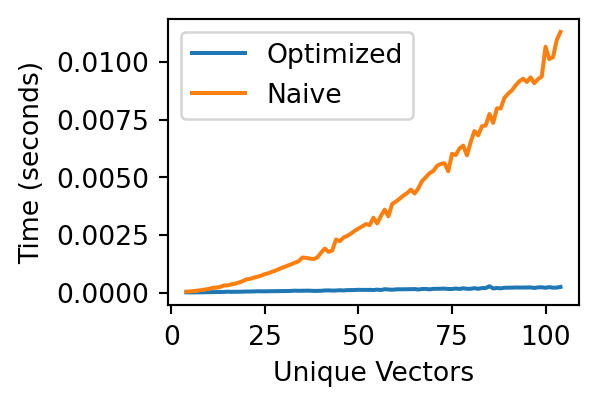

In [54]:
plt.figure(figsize=(3, 2), layout="constrained")
#plt.plot(d1)
plt.plot(point_counts, d2, label="Optimized")
plt.plot(point_counts, d3, label="Naive")
plt.xlabel("Unique Vectors")
plt.ylabel("Time (seconds)")
plt.legend()

plt.savefig("nbor-runtime.pdf")

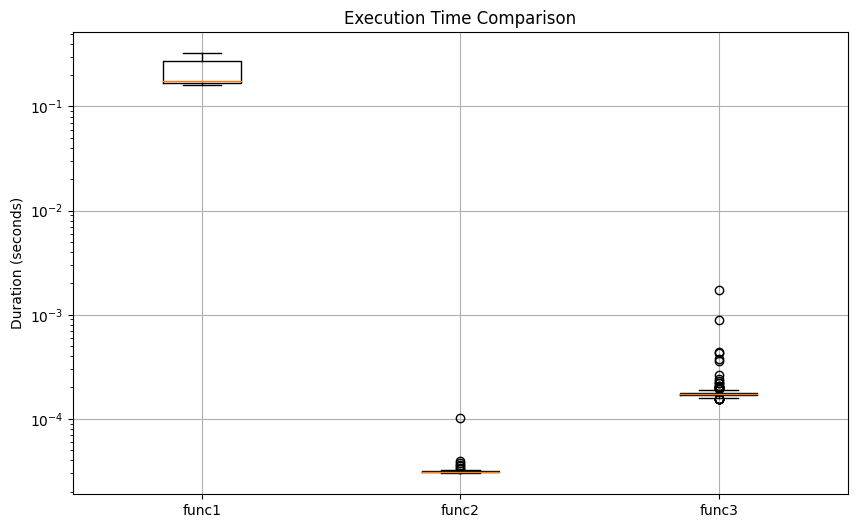

In [21]:
# Record durations
def get_durations(func, count):
    durations_func1 = []
    for _ in tqdm(range(count)):
        start = time.perf_counter()
        func()
        end = time.perf_counter()
        durations_func1.append(end - start)
    return durations_func1

count = 100
durations_func1 = get_durations(func1, count)
durations_func2 = get_durations(func2, count)
durations_func3 = get_durations(func3, count)

# Plot boxplot
plt.figure(figsize=(10, 6))
plt.boxplot([durations_func1, durations_func2, durations_func3], labels=['func1', 'func2', 'func3'])
plt.ylabel('Duration (seconds)')
plt.title('Execution Time Comparison')
plt.yscale('log')
plt.grid(True)